# Experiment 2: Multiple Datasets — DP-GMM Generalization

**Runs DP-GMM (BayesianGaussianMixture) on four datasets:**
1. Iris (4 features, 3 classes)
2. Wine (13 features, 3 classes)
3. Old Faithful Geyser (2 features, ~2 clusters)
4. Synthetic blobs (2 features, 5 clusters)

Demonstrates that DP-GMM can automatically infer cluster count across diverse data structures.

**Reference:** Görür & Rasmussen (2010). JCST 25(4), 615–626.

## 1. Imports & Setup

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_wine, make_blobs
from sklearn.mixture import BayesianGaussianMixture
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

%matplotlib inline

PLOTS_DIR = os.path.join('..', 'results', 'plots')
DATA_DIR = os.path.join('..', 'dataset')
os.makedirs(PLOTS_DIR, exist_ok=True)

## 2. Prepare Datasets

In [13]:
datasets = {}

# 1. Iris
iris = load_iris()
datasets['Iris'] = {
    'X': iris.data, 'y': iris.target,
    'expected_k': 3, 'desc': '4 features, 150 samples, 3 species'
}

# 2. Wine
wine = load_wine()
datasets['Wine'] = {
    'X': wine.data, 'y': wine.target,
    'expected_k': 3, 'desc': '13 features, 178 samples, 3 cultivars'
}

# 3. Old Faithful Geyser
geyser_path = os.path.join(DATA_DIR, '/content/old_faithful.csv')
geyser_data = np.genfromtxt(geyser_path, delimiter=',', skip_header=1)
datasets['Old Faithful'] = {
    'X': geyser_data, 'y': None,
    'expected_k': 2, 'desc': '2 features (eruption, waiting), ~2 clusters'
}

# 4. Synthetic blobs
X_syn, y_syn = make_blobs(n_samples=300, centers=5, cluster_std=1.0, random_state=42)
datasets['Synthetic'] = {
    'X': X_syn, 'y': y_syn,
    'expected_k': 5, 'desc': '2 features, 300 samples, 5 blobs'
}

for name, data in datasets.items():
    print(f"  {name}: {data['desc']}")

  Iris: 4 features, 150 samples, 3 species
  Wine: 13 features, 178 samples, 3 cultivars
  Old Faithful: 2 features (eruption, waiting), ~2 clusters
  Synthetic: 2 features, 300 samples, 5 blobs


## 3. Run DP-GMM on All Datasets

In [14]:
results = []
all_labels = {}

for name, data in datasets.items():
    X = data['X']
    y = data['y']
    expected_k = data['expected_k']

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    dpgmm = BayesianGaussianMixture(
        n_components=15,
        covariance_type='full',
        weight_concentration_prior_type='dirichlet_process',
        weight_concentration_prior=1.0,
        max_iter=500,
        random_state=42,
        init_params='kmeans'
    )
    dpgmm.fit(X_scaled)
    labels = dpgmm.predict(X_scaled)
    all_labels[name] = labels

    n_clusters = len(np.unique(labels))
    sil = silhouette_score(X_scaled, labels) if n_clusters > 1 else 0.0
    ari = adjusted_rand_score(y, labels) if y is not None else 'N/A'

    results.append({
        'Dataset': name, 'Expected K': expected_k,
        'Detected K': n_clusters, 'ARI': ari,
        'Silhouette': sil, 'Description': data['desc']
    })

## 4. Results Table

In [15]:
print(f"{'Dataset':<15} {'Expected K':>12} {'Detected K':>12} {'ARI':>10} {'Silhouette':>12}")
print("-" * 63)
for r in results:
    ari_str = f"{r['ARI']:.4f}" if isinstance(r['ARI'], float) else r['ARI']
    print(f"{r['Dataset']:<15} {r['Expected K']:>12} {r['Detected K']:>12} "
          f"{ari_str:>10} {r['Silhouette']:>12.4f}")
print("-" * 63)

for r in results:
    match = "✅" if r['Detected K'] == r['Expected K'] else "⚠️"
    print(f"  {match} {r['Dataset']}: detected {r['Detected K']} clusters "
          f"(expected {r['Expected K']})")

Dataset           Expected K   Detected K        ARI   Silhouette
---------------------------------------------------------------
Iris                       3            6     0.5342       0.2191
Wine                       3           15     0.2388       0.1200
Old Faithful               2            2        N/A       0.7400
Synthetic                  5            4     0.7803       0.7336
---------------------------------------------------------------
  ⚠️ Iris: detected 6 clusters (expected 3)
  ⚠️ Wine: detected 15 clusters (expected 3)
  ✅ Old Faithful: detected 2 clusters (expected 2)
  ⚠️ Synthetic: detected 4 clusters (expected 5)


## 5. Visualization: 2×2 Grid

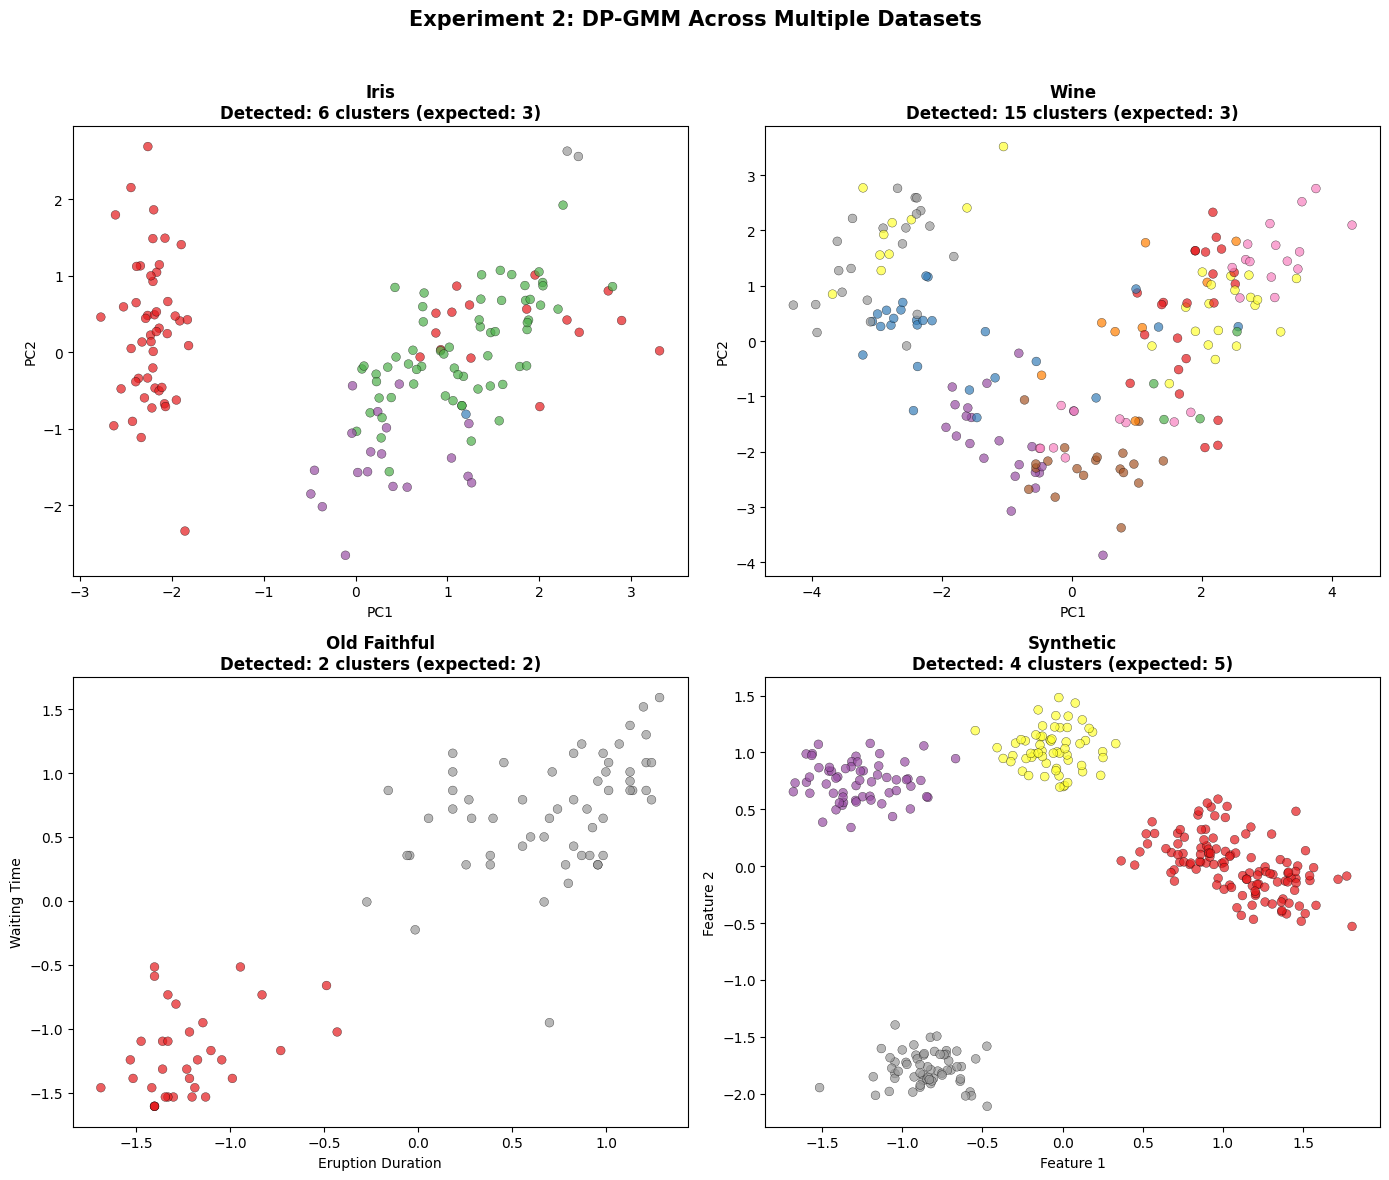


🏁 Experiment 2 complete.


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (name, data) in enumerate(datasets.items()):
    ax = axes[idx]
    X = data['X']
    labels = all_labels[name]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    if X_scaled.shape[1] > 2:
        pca = PCA(n_components=2)
        X_2d = pca.fit_transform(X_scaled)
        xlabel, ylabel = 'PC1', 'PC2'
    else:
        X_2d = X_scaled
        if name == 'Old Faithful':
            xlabel, ylabel = 'Eruption Duration', 'Waiting Time'
        else:
            xlabel, ylabel = 'Feature 1', 'Feature 2'

    n_clusters = len(np.unique(labels))
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels,
               cmap='Set1', alpha=0.7, edgecolors='k', linewidth=0.3, s=40)
    ax.set_title(f'{name}\nDetected: {n_clusters} clusters (expected: {data["expected_k"]})',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)

plt.suptitle('Experiment 2: DP-GMM Across Multiple Datasets',
             fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(PLOTS_DIR, 'exp2_multiple_datasets.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n🏁 Experiment 2 complete.")